Histogram

In [71]:
import matplotlib.pyplot as plt

In [73]:
import pandas as pd

In [75]:
hr = pd.read_csv('Dataset/HR_Dataset Refresh.csv')
hr.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [122]:
clean_salary = hr['Salary']<102000
hr = hr[clean_salary]



<function matplotlib.pyplot.show(close=None, block=None)>

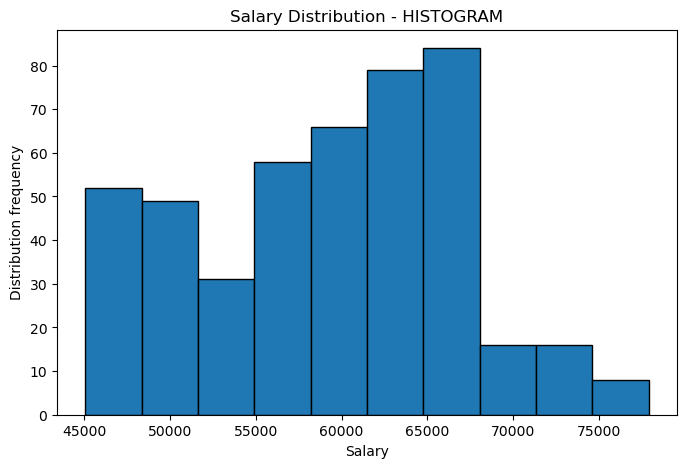

In [124]:
plt.figure(figsize=(8,5))
plt.hist(hr['Salary'], edgecolor = 'black')
plt.xlabel('Salary')
plt.ylabel('Distribution frequency')
plt.title('Salary Distribution - HISTOGRAM')
plt.show

In [126]:

import seaborn as sns

In [128]:
 mean_salary= hr['Salary'].mean()
median_salary = hr['Salary'].median()

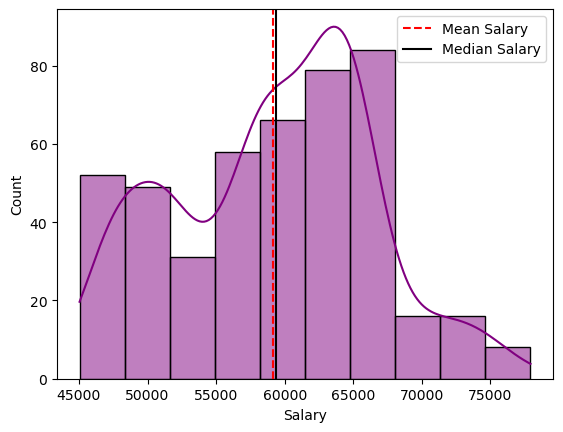

In [130]:
#KDE -> Kernel Density Estimate
# axvline -> axis vertical line
sns.histplot(hr['Salary'], bins=10, kde= True, color= 'purple')
plt.axvline(mean_salary, color ='red', label = 'Mean Salary', ls='--')
plt.axvline(median_salary, color ='black', label ='Median Salary' )
plt.legend()

BOX PLOT

In [137]:
clean_salary = hr['Salary']<80000
hr = hr[clean_salary]

<Axes: ylabel='Salary'>

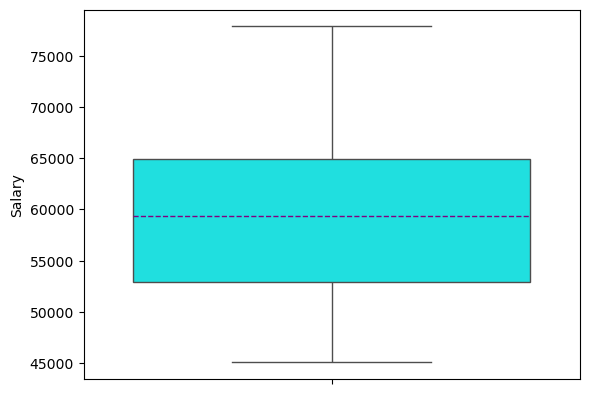

In [155]:
#wishker plot
#T-shape -> Wishkers ()
#If bigger above right skewness otherwise left 
#circle -> outlier 
sns.boxplot(hr['Salary'], color='aqua',medianprops={'color':'purple','linestyle':'--'})

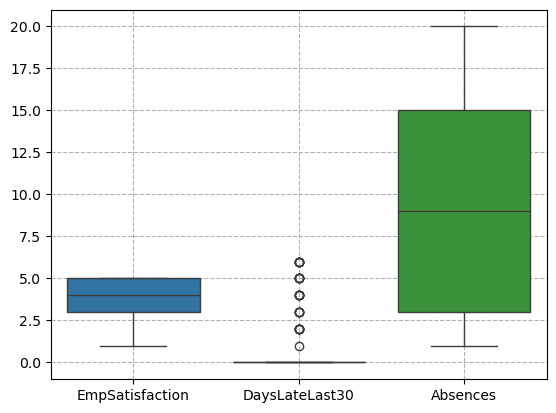

In [157]:
sns.boxplot(hr[['EmpSatisfaction','DaysLateLast30','Absences']])
plt.grid(ls='dashed')

BAR CHART(Column chart, stacked chart) 

In [162]:
#Find the employees by each department and its performance score.


In [181]:
dep_perf = hr.groupby(['Department', 'PerformanceScore'])['EmpID'].count().reset_index().rename(columns={'EmpID': 'Total_Employees'})

dep_perf

,Department,PerformanceScore,Total_Employees
0,Admin Offices,Fully Meets,6
1,IT/IS,Exceeds,1
2,IT/IS,Fully Meets,12
3,IT/IS,PIP,1
4,Production,Exceeds,85
5,Production,Fully Meets,301
6,Production,Needs Improvement,14
7,Production,PIP,8
8,Sales,Exceeds,2
9,Sales,Fully Meets,23


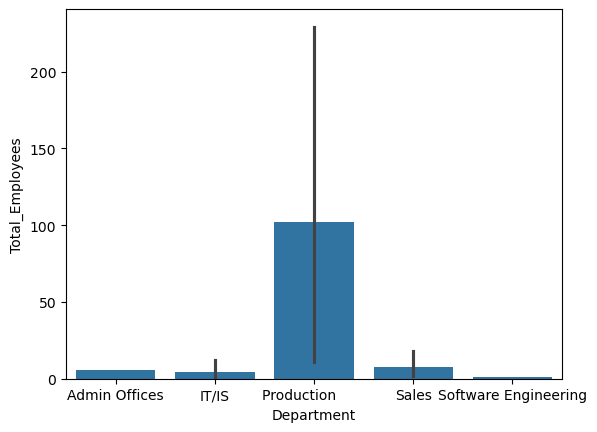

In [183]:
sns.barplot(data=dep_perf, x='Department', y='Total_Employees')
plt.show()


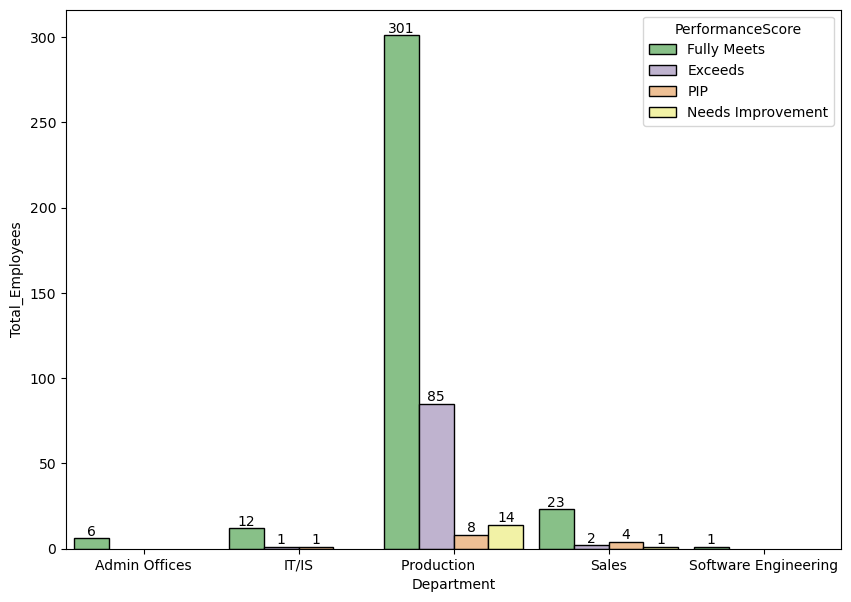

In [201]:
plt.figure(figsize=(10,7))
ax=sns.barplot(x='Department', y='Total_Employees', data=dep_perf, errorbar=None, hue='PerformanceScore',palette='Accent', width=0.9,edgecolor='black')
for container in ax.containers:
    plt.bar_label(container)
